In [1]:
# =========================================================
# IMPORT LIBRARY
# =========================================================
import os
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# =========================
# CEK DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device yang digunakan:", device)

Device yang digunakan: cpu


In [3]:
# =========================
# PATH DATASET HASIL PREPROCESSING
# =========================
DATASET_DIR = r"D:\REVA\skripsi\01. Dataset\01. Internal\dataset_resized_split_60_20_20"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

In [4]:
# =========================================================
# TRANSFORM DATA
# =========================================================
train_transform_non_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
# =========================
# LOAD DATASET
# =========================
train_dataset = ImageFolder(TRAIN_DIR, transform=train_transform_non_aug)
val_dataset   = ImageFolder(VAL_DIR, transform=val_test_transform)
test_dataset  = ImageFolder(TEST_DIR, transform=val_test_transform)

# =========================
# DATALOADER
# =========================
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes :", class_names)
print("Jumlah kelas :", num_classes)
print("Train data :", len(train_dataset))
print("Validation data :", len(val_dataset))
print("Test data :", len(test_dataset))

Classes : ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Jumlah kelas : 4
Train data : 2528
Validation data : 841
Test data : 848


In [6]:
from collections import Counter

# Ambil label dari dataset
targets = train_dataset.targets

# Hitung jumlah tiap kelas
class_counts = Counter(targets)

# Tampilkan jumlah data per kelas
print("Jumlah data train per kelas:\n")

for class_id, count in class_counts.items():
    class_name = train_dataset.classes[class_id]
    print(f"{class_name} : {count}")

Jumlah data train per kelas:

cataract : 622
diabetic_retinopathy : 658
glaucoma : 604
normal : 644


In [7]:
import torchvision.models as models
import torch
import torch.nn as nn

# =========================
# LOAD MODEL SQUEEZENET 1.1
# =========================
model_squeezenet = models.squeezenet1_1(pretrained=True)

# =========================
# FREEZE SEMUA PARAMETER
# =========================
for param in model_squeezenet.parameters():
    param.requires_grad = False

# =========================
# PARTIAL FINE-TUNING
# Buka Fire7, Fire8 dan Fire9
# =========================
for param in model_squeezenet.features[10:].parameters():
    param.requires_grad = True

# =========================
# AMBIL JUMLAH FEATURE
# =========================
in_features = model_squeezenet.classifier[1].in_channels

# =========================
# GANTI CLASSIFIER
# =========================
model_squeezenet.classifier = nn.Sequential(
    nn.AdaptiveAvgPool2d((1,1)),
    nn.Flatten(),
    nn.Dropout(p=0.5),
    nn.Linear(in_features, num_classes)
)

# =========================
# CLASSIFIER TRAINABLE
# =========================
for param in model_squeezenet.classifier.parameters():
    param.requires_grad = True

# =========================
# KIRIM KE DEVICE
# =========================
model = model_squeezenet.to(device)

# =========================
# MODEL SUMMARY
# =========================
from torchinfo import summary

summary(
    model,
    input_size=(1,3,224,224)
)

C:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Layer (type:depth-idx)                   Output Shape              Param #
SqueezeNet                               [1, 4]                    --
├─Sequential: 1-1                        [1, 512, 13, 13]          --
│    └─Conv2d: 2-1                       [1, 64, 111, 111]         (1,792)
│    └─ReLU: 2-2                         [1, 64, 111, 111]         --
│    └─MaxPool2d: 2-3                    [1, 64, 55, 55]           --
│    └─Fire: 2-4                         [1, 128, 55, 55]          --
│    │    └─Conv2d: 3-1                  [1, 16, 55, 55]           (1,040)
│    │    └─ReLU: 3-2                    [1, 16, 55, 55]           --
│    │    └─Conv2d: 3-3                  [1, 64, 55, 55]           (1,088)
│    │    └─ReLU: 3-4                    [1, 64, 55, 55]           --
│    │    └─Conv2d: 3-5                  [1, 64, 55, 55]           (9,280)
│    │    └─ReLU: 3-6                    [1, 64, 55, 55]           --
│    └─Fire: 2-5                         [1, 128, 55, 55]        

In [8]:
# =========================
# FUNGSI MENGHITUNG PARAMETER
# =========================
def count_parameters(model, model_name="Model"):

    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = total - trainable

    print(f"\n=== {model_name} ===")
    print(f"Total Parameter     : {total:,}")
    print(f"Trainable Parameter : {trainable:,}")
    print(f"Frozen Parameter    : {frozen:,}")

# Hitung parameter untuk SqueezeNet Partial Fine-Tuning
count_parameters(model, "SqueezeNet 1.1 Partial Fine-Tuning")


=== SqueezeNet 1.1 Partial Fine-Tuning ===
Total Parameter     : 724,548
Trainable Parameter : 499,252
Frozen Parameter    : 225,296


In [9]:
# =========================
# FUNGSI CEK LAYER TRAINABLE
# =========================
def check_trainable_layers(model, model_name="Model"):

    trainable_layers = sum(p.requires_grad for p in model.parameters())
    total_layers = sum(1 for _ in model.parameters())

    print(f"\n=== {model_name} ===")
    print(f"Trainable layers : {trainable_layers}")
    print(f"Total layers     : {total_layers}")

# Cek untuk SqueezeNet 1.1 Partial Fine-Tuning
check_trainable_layers(model, "SqueezeNet 1.1 Partial Fine-Tuning")


=== SqueezeNet 1.1 Partial Fine-Tuning ===
Trainable layers : 20
Total layers     : 52


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

# =========================
# LOSS FUNCTION
# =========================
# Dataset relatif seimbang sehingga tidak menggunakan class weight
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

# =========================
# OPTIMIZER (SQUEEZENET PARTIAL FINE-TUNING)
# =========================
# Parameter yang dioptimasi:
# fire7, fire8, fire9, dan classifier
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0005,          # learning rate
    weight_decay=1e-4   # regularisasi
)

# =========================
# LEARNING RATE SCHEDULER
# =========================
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

In [11]:
import time
import torch

# =========================
# TRAINING FUNCTION (SQUEEZENET PARTIAL FINE-TUNING)
# =========================
def train_model(model, train_loader, val_loader, epochs=30):

    train_loss, val_loss = [], []
    train_acc, val_acc = [], []

    best_acc = 0.0
    best_train_acc = 0.0   # <-- tambahan

    start_training = time.time()

    for epoch in range(epochs):

        start_epoch = time.time()

        # =========================
        # TRAINING
        # =========================
        model.train()
        correct, total, running_loss = 0, 0, 0

        for imgs, labels in train_loader:

            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                filter(lambda p: p.requires_grad, model.parameters()),
                max_norm=1.0
            )

            optimizer.step()

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epoch_train_loss = running_loss / len(train_loader)
        epoch_train_acc = correct / total

        train_loss.append(epoch_train_loss)
        train_acc.append(epoch_train_acc)

        # =========================
        # SIMPAN BEST TRAIN ACC
        # =========================
        if epoch_train_acc > best_train_acc:
            best_train_acc = epoch_train_acc

        # =========================
        # VALIDATION
        # =========================
        model.eval()
        correct, total, running_loss = 0, 0, 0

        with torch.no_grad():

            for imgs, labels in val_loader:

                imgs, labels = imgs.to(device), labels.to(device)

                outputs = model(imgs)
                loss = criterion(outputs, labels)

                running_loss += loss.item()

                _, preds = torch.max(outputs, 1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        epoch_val_loss = running_loss / len(val_loader)
        epoch_val_acc = correct / total

        val_loss.append(epoch_val_loss)
        val_acc.append(epoch_val_acc)

        # =========================
        # LR SCHEDULER
        # =========================
        scheduler.step(epoch_val_loss)

        # =========================
        # SAVE BEST MODEL
        # =========================
        if epoch_val_acc > best_acc:

            best_acc = epoch_val_acc

            torch.save(
                model.state_dict(),
                "best_squeezenet_partial_finetuning_revisi.pth"
            )

            print(">> Best model disimpan dengan Val Acc:", best_acc)

        # =========================
        # WAKTU EPOCH
        # =========================
        epoch_time = time.time() - start_epoch

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"Train Acc: {epoch_train_acc:.4f} | "
            f"Val Acc: {epoch_val_acc:.4f} | "
            f"Time: {epoch_time:.2f}s"
        )

    total_time = time.time() - start_training

    print("\nTraining selesai.")
    print(f"Best Train Accuracy      : {best_train_acc:.4f}")
    print(f"Best Validation Accuracy : {best_acc:.4f}")
    print(f"Total Training Time      : {total_time/60:.2f} menit")

    return train_loss, val_loss, train_acc, val_acc

In [12]:
# =========================
# TRAIN MODEL (SQUEEZENET 1.1 PARTIAL FINE-TUNING)
# =========================
history_squeezenet_partial = train_model(
    model,        # model SqueezeNet Partial Fine-Tuning
    train_loader,
    val_loader,
    epochs=30
)

>> Best model disimpan dengan Val Acc: 0.8394768133174791
Epoch [1/30] | Train Loss: 1.0086 | Val Loss: 0.7010 | Train Acc: 0.6590 | Val Acc: 0.8395 | Time: 33.24s
>> Best model disimpan dengan Val Acc: 0.8941736028537456
Epoch [2/30] | Train Loss: 0.7253 | Val Loss: 0.5926 | Train Acc: 0.8240 | Val Acc: 0.8942 | Time: 32.52s
Epoch [3/30] | Train Loss: 0.6515 | Val Loss: 0.5751 | Train Acc: 0.8651 | Val Acc: 0.8823 | Time: 32.59s
>> Best model disimpan dengan Val Acc: 0.9084423305588585
Epoch [4/30] | Train Loss: 0.6031 | Val Loss: 0.5410 | Train Acc: 0.8877 | Val Acc: 0.9084 | Time: 33.81s
Epoch [5/30] | Train Loss: 0.5719 | Val Loss: 0.5345 | Train Acc: 0.9082 | Val Acc: 0.9049 | Time: 35.59s
Epoch [6/30] | Train Loss: 0.5451 | Val Loss: 0.5432 | Train Acc: 0.9189 | Val Acc: 0.9025 | Time: 34.76s
>> Best model disimpan dengan Val Acc: 0.9096313912009513
Epoch [7/30] | Train Loss: 0.5325 | Val Loss: 0.5440 | Train Acc: 0.9225 | Val Acc: 0.9096 | Time: 34.87s
>> Best model disimpan den

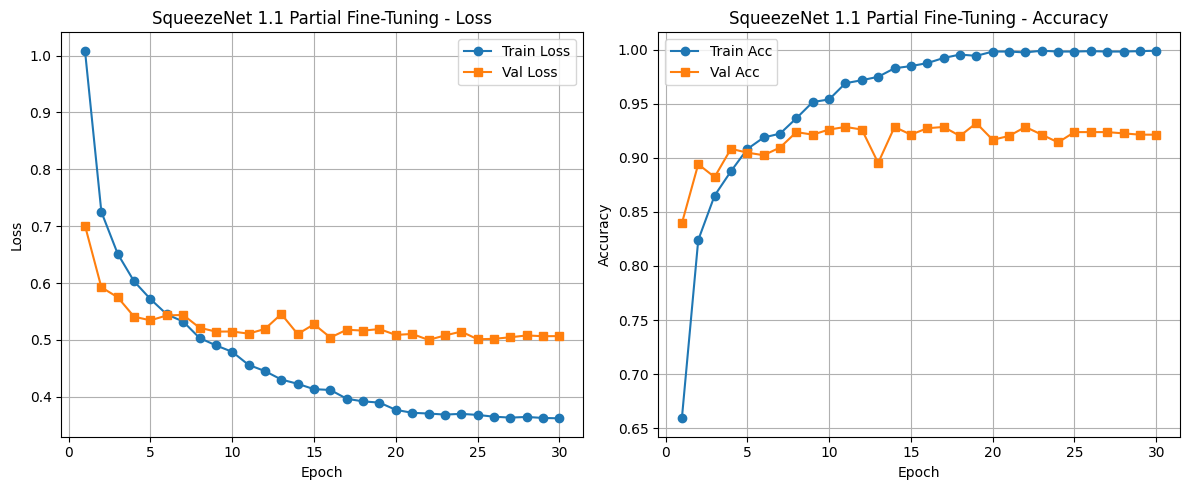

In [13]:
# =========================
# VISUALISASI LEARNING CURVE (SQUEEZENET PARTIAL FINE-TUNING)
# =========================

import matplotlib.pyplot as plt

train_loss_p, val_loss_p, train_acc_p, val_acc_p = history_squeezenet_partial
epochs = range(1, len(train_acc_p) + 1)

plt.figure(figsize=(12,5))

# ======================
# LOSS
# ======================
plt.subplot(1,2,1)

plt.plot(epochs, train_loss_p, marker='o', label='Train Loss')
plt.plot(epochs, val_loss_p, marker='s', label='Val Loss')

plt.legend()
plt.title("SqueezeNet 1.1 Partial Fine-Tuning - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

# ======================
# ACCURACY
# ======================
plt.subplot(1,2,2)

plt.plot(epochs, train_acc_p, marker='o', label='Train Acc')
plt.plot(epochs, val_acc_p, marker='s', label='Val Acc')

plt.legend()
plt.title("SqueezeNet 1.1 Partial Fine-Tuning - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
# =========================
# CLASSIFICATION REPORT (SQUEEZENET 1.1 PARTIAL FINE-TUNING)
# =========================

from sklearn.metrics import classification_report
import numpy as np

print("\n=== Classification Report - SqueezeNet 1.1 Partial Fine-Tuning ===")

# Pastikan model dalam mode evaluasi
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Cetak classification report
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
))


=== Classification Report - SqueezeNet 1.1 Partial Fine-Tuning ===
                      precision    recall  f1-score   support

            cataract     0.9136    0.9617    0.9371       209
diabetic_retinopathy     0.9955    1.0000    0.9977       221
            glaucoma     0.9226    0.7079    0.8011       202
              normal     0.7928    0.9213    0.8522       216

            accuracy                         0.9009       848
           macro avg     0.9061    0.8977    0.8970       848
        weighted avg     0.9063    0.9009    0.8989       848



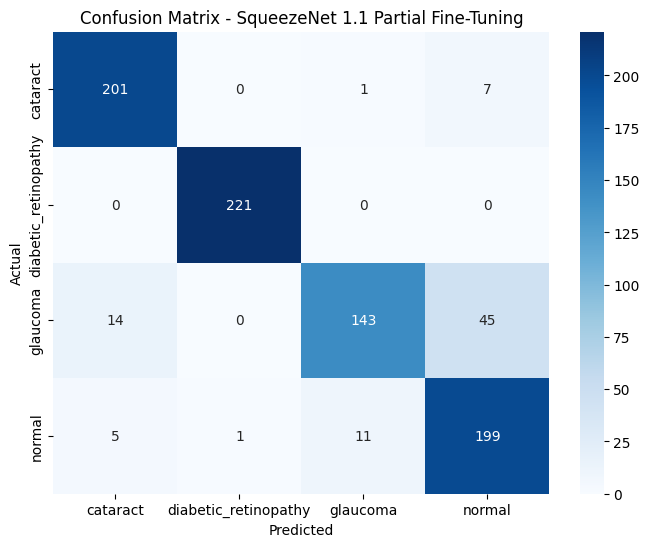

In [15]:
# =========================
# CONFUSION MATRIX (SQUEEZENET 1.1 PARTIAL FINE-TUNING)
# =========================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Hitung confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SqueezeNet 1.1 Partial Fine-Tuning")
plt.show()

In [16]:
from sklearn.metrics import accuracy_score

# =========================
# TRAIN ACCURACY
# =========================
train_loss_p, val_loss_p, train_acc_p, val_acc_p = history_squeezenet_partial

# =========================
# VALIDATION ACCURACY
# =========================
val_accuracy_best = max(val_acc_p)

# =========================
# TEST ACCURACY
# =========================
test_accuracy = accuracy_score(all_labels, all_preds)

print("\n=== FINAL MODEL PERFORMANCE ===")
print(f"Validation Accuracy : {val_accuracy_best:.4f}")
print(f"Test Accuracy       : {test_accuracy:.4f}")


=== FINAL MODEL PERFORMANCE ===
Validation Accuracy : 0.9322
Test Accuracy       : 0.9009



=== Akurasi Per Kelas - SqueezeNet 1.1 Partial Fine-Tuning ===
cataract : 96.17% (201/209)
diabetic_retinopathy : 100.00% (221/221)
glaucoma : 70.79% (143/202)
normal : 92.13% (199/216)

Rata-rata Akurasi Per Kelas : 89.77%


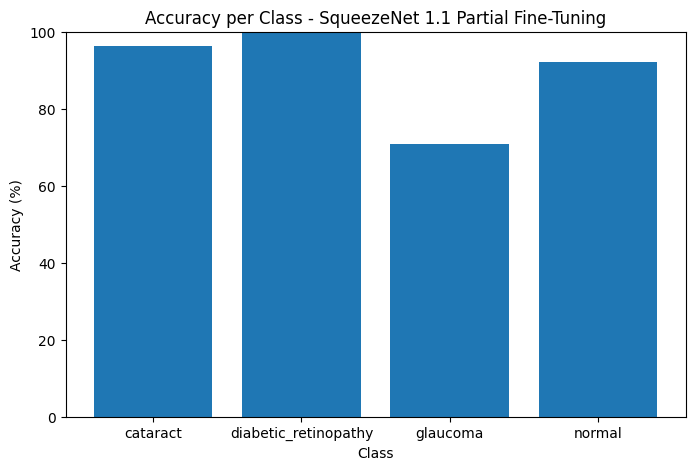

In [17]:
import numpy as np
from collections import defaultdict
import torch
import matplotlib.pyplot as plt

# ===============================
# NAMA EKSPERIMEN
# ===============================
experiment_name = "SqueezeNet 1.1 Partial Fine-Tuning"

model.eval()

class_correct = defaultdict(int)
class_total = defaultdict(int)

# ===============================
# HITUNG AKURASI PER KELAS
# ===============================
with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        # Loop setiap sample
        for label, pred in zip(labels.cpu(), preds.cpu()):

            label_idx = label.item()
            class_total[label_idx] += 1

            if label_idx == pred.item():
                class_correct[label_idx] += 1


# ===============================
# TAMPILKAN HASIL
# ===============================
print(f"\n=== Akurasi Per Kelas - {experiment_name} ===")

classes = test_loader.dataset.classes
per_class_acc = []

for i in range(len(classes)):

    total = class_total[i]
    correct = class_correct[i]

    acc = 0 if total == 0 else (correct / total) * 100
    per_class_acc.append(acc)

    print(f"{classes[i]} : {acc:.2f}% ({correct}/{total})")


# ===============================
# RATA-RATA AKURASI PER KELAS
# ===============================
avg_acc = np.mean(per_class_acc)
print(f"\nRata-rata Akurasi Per Kelas : {avg_acc:.2f}%")


# ===============================
# VISUALISASI AKURASI PER KELAS
# ===============================
plt.figure(figsize=(8,5))
plt.bar(classes, per_class_acc)

plt.title("Accuracy per Class - SqueezeNet 1.1 Partial Fine-Tuning")
plt.xlabel("Class")
plt.ylabel("Accuracy (%)")

plt.ylim(0,100)

plt.show()

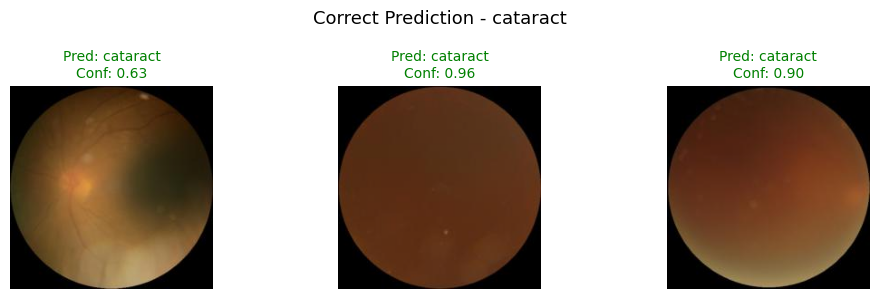

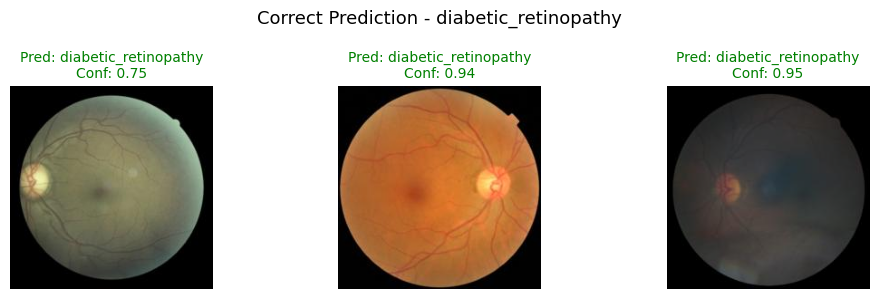

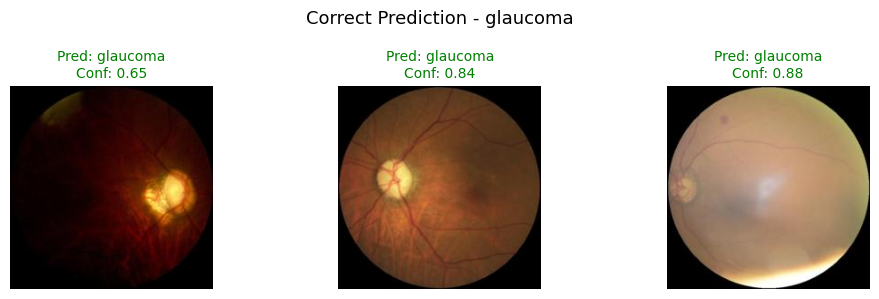

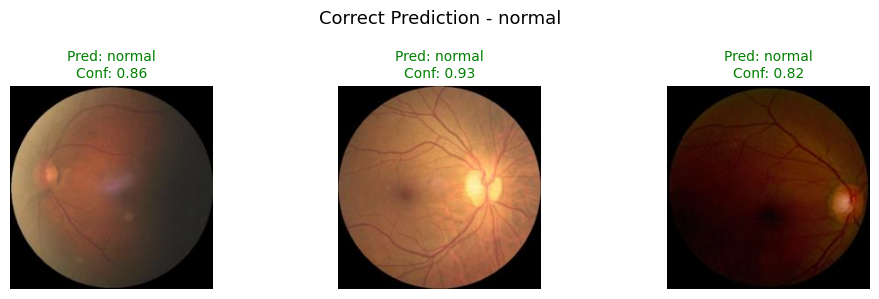

In [18]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

samples_per_class = 3
model.eval()

classes = test_loader.dataset.classes
num_classes = len(classes)

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

def denormalize(img):
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
    return img

# ===============================
# Ambil sample BENAR per kelas
# ===============================
correct_samples = {i: [] for i in range(num_classes)}

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        confs, preds = torch.max(probs, 1)

        for img, label, pred, conf in zip(images.cpu(), labels, preds.cpu(), confs.cpu()):

            label_idx = label.item()

            if pred.item() == label_idx:
                if len(correct_samples[label_idx]) < samples_per_class:
                    correct_samples[label_idx].append((img, label_idx, pred.item(), conf.item()))

# ===============================
# VISUALISASI
# ===============================
for class_idx in range(num_classes):

    samples = correct_samples[class_idx]
    if len(samples) == 0:
        continue

    plt.figure(figsize=(10,3))

    for i, (img, label, pred, conf) in enumerate(samples):

        plt.subplot(1, samples_per_class, i+1)

        img = denormalize(img)
        img = img.permute(1,2,0).numpy()

        plt.imshow(img)
        plt.axis("off")

        plt.title(
            f"Pred: {classes[pred]}\nConf: {conf:.2f}",
            color="green",
            fontsize=10
        )

    plt.suptitle(
        f"Correct Prediction - {classes[class_idx]}",
        fontsize=13
    )

    plt.tight_layout()
    plt.show()

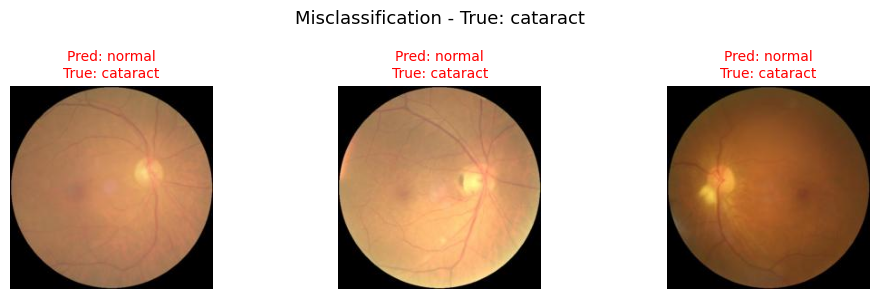

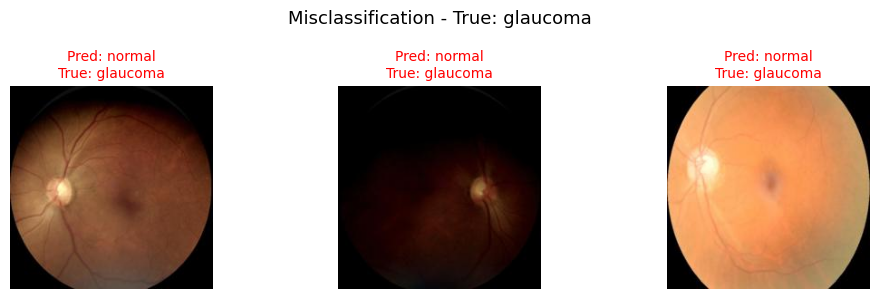

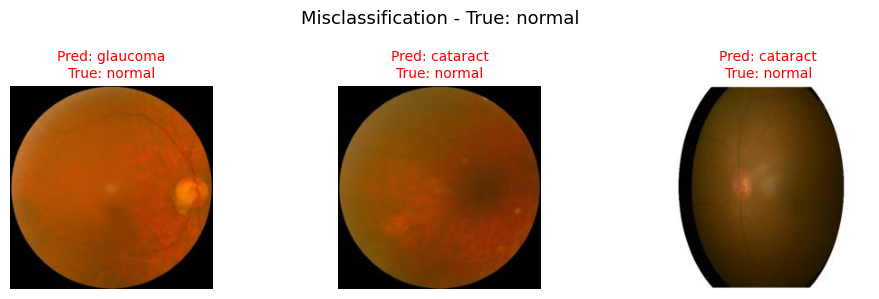

In [19]:
import torch
import matplotlib.pyplot as plt

samples_per_class = 3
wrong_samples = {i: [] for i in range(num_classes)}

model.eval()

# ===============================
# AMBIL SAMPLE SALAH
# ===============================
with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for img, label, pred in zip(images.cpu(), labels, preds.cpu()):

            label_idx = label.item()

            if pred.item() != label_idx:
                if len(wrong_samples[label_idx]) < samples_per_class:
                    wrong_samples[label_idx].append((img, label_idx, pred.item()))

# ===============================
# VISUALISASI
# ===============================
for class_idx in range(num_classes):

    samples = wrong_samples[class_idx]
    if len(samples) == 0:
        continue

    plt.figure(figsize=(10,3))

    for i, (img, label, pred) in enumerate(samples):

        plt.subplot(1, samples_per_class, i+1)

        img = denormalize(img)
        img = img.permute(1,2,0).numpy()

        plt.imshow(img)
        plt.axis("off")

        plt.title(
            f"Pred: {classes[pred]}\nTrue: {classes[label]}",
            color="red",
            fontsize=10
        )

    plt.suptitle(
        f"Misclassification - True: {classes[class_idx]}",
        fontsize=13
    )

    plt.tight_layout()
    plt.show()

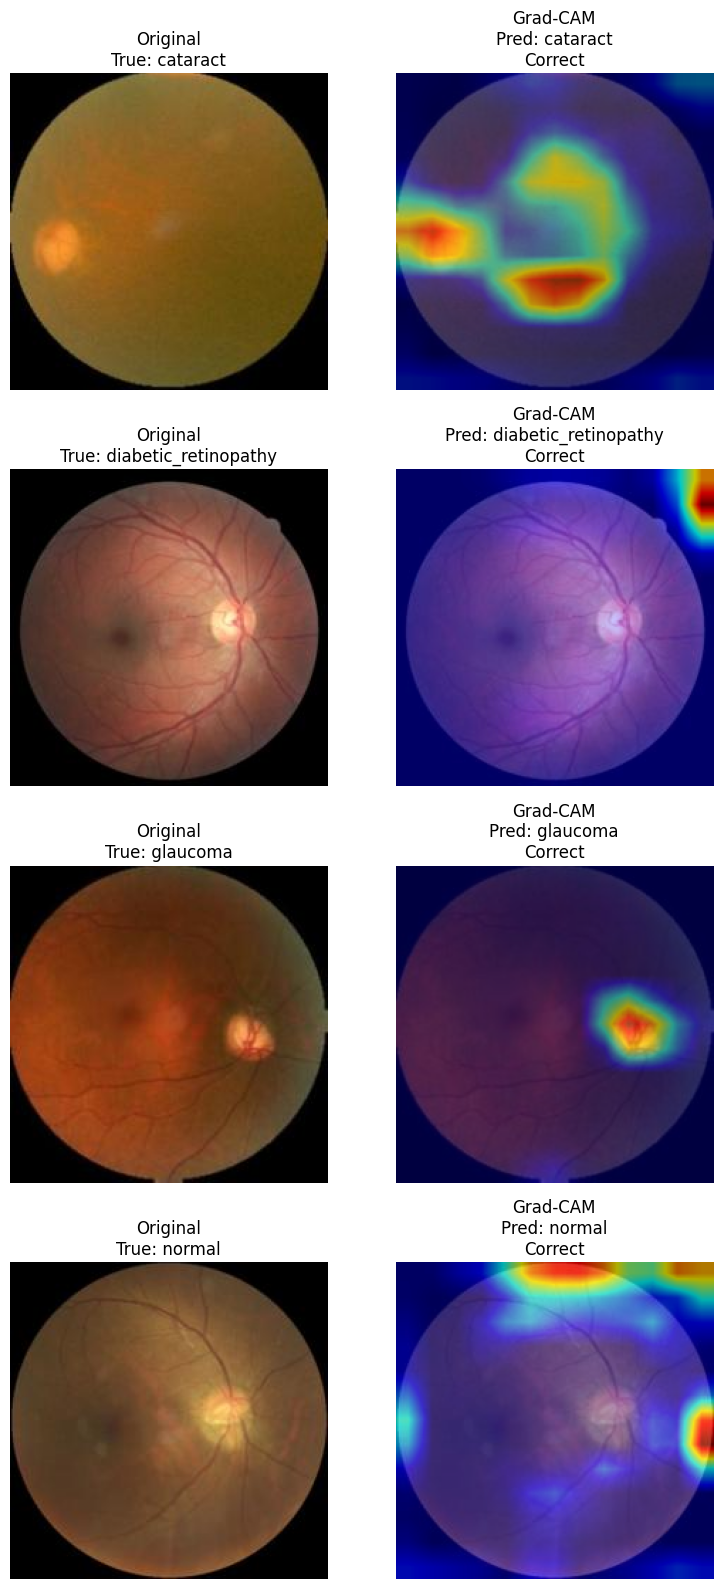

In [20]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import matplotlib.pyplot as plt
import numpy as np
import torch

from PIL import Image
from torchvision import transforms

# ===============================
# EVAL MODE
# ===============================
model.eval()

# ===============================
# CLASS NAMES
# ===============================
class_names = [
    'cataract',
    'diabetic_retinopathy',
    'glaucoma',
    'normal'
]

# ===============================
# IMAGE PATHS
# ===============================
image_paths = {
    "cataract": r"D:\REVA\skripsi\01. Dataset\01. Internal\dataset_resized_split_60_20_20\test\cataract\_23_5187079.jpg",

    "diabetic_retinopathy": r"D:\REVA\skripsi\01. Dataset\01. Internal\dataset_resized_split_60_20_20\test\diabetic_retinopathy\129_right.jpeg",

    "glaucoma": r"D:\REVA\skripsi\01. Dataset\01. Internal\dataset_resized_split_60_20_20\test\glaucoma\_159_52965.jpg",

    "normal": r"D:\REVA\skripsi\01. Dataset\01. Internal\dataset_resized_split_60_20_20\test\normal\2353_right.jpg"
}

# ===============================
# TARGET LAYER (FIX)
# ===============================
target_layers = [model.features[12].expand3x3]

# ===============================
# INIT CAM
# ===============================
cam = GradCAM(
    model=model,
    target_layers=target_layers
)

# ===============================
# TRANSFORM
# ===============================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ===============================
# FIGURE
# ===============================
fig, axes = plt.subplots(
    len(image_paths),
    2,
    figsize=(8, 4 * len(image_paths))
)

if len(image_paths) == 1:
    axes = np.expand_dims(axes, axis=0)

# ===============================
# LOOP
# ===============================
for idx, (true_label, img_path) in enumerate(image_paths.items()):

    # ===============================
    # LOAD IMAGE
    # ===============================
    img_pil = Image.open(img_path).convert("RGB")

    # ===============================
    # PREPROCESS
    # ===============================
    input_tensor = transform(img_pil).unsqueeze(0).to(device)

    # IMPORTANT
    input_tensor.requires_grad = True

    # ===============================
    # FORWARD
    # ===============================
    output = model(input_tensor)

    pred_class = torch.argmax(output, dim=1).item()

    pred_name = class_names[pred_class]

    # ===============================
    # STATUS
    # ===============================
    status = (
        "Correct"
        if true_label == pred_name
        else "Wrong"
    )

    # ===============================
    # GENERATE CAM
    # ===============================
    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=[ClassifierOutputTarget(pred_class)]
    )[0]

    # ===============================
    # ORIGINAL IMAGE
    # ===============================
    img = np.array(
        img_pil.resize((224, 224))
    ).astype(np.float32) / 255.0

    # ===============================
    # OVERLAY CAM
    # ===============================
    visualization = show_cam_on_image(
        img,
        grayscale_cam,
        use_rgb=True
    )

    # ===============================
    # ORIGINAL
    # ===============================
    axes[idx, 0].imshow(img)

    axes[idx, 0].set_title(
        f"Original\nTrue: {true_label}",
        fontsize=12
    )

    axes[idx, 0].axis("off")

    # ===============================
    # GRADCAM
    # ===============================
    axes[idx, 1].imshow(visualization)

    axes[idx, 1].set_title(
        f"Grad-CAM\nPred: {pred_name}\n{status}",
        fontsize=12
    )

    axes[idx, 1].axis("off")

# ===============================
# SHOW
# ===============================
plt.tight_layout()
plt.show()


=== DAFTAR MISCLASSIFICATION ===
True: cataract → Pred: normal
True: cataract → Pred: glaucoma
True: glaucoma → Pred: normal
True: glaucoma → Pred: cataract
True: normal → Pred: glaucoma
True: normal → Pred: cataract
True: normal → Pred: diabetic_retinopathy

Menampilkan: True cataract → Pred normal


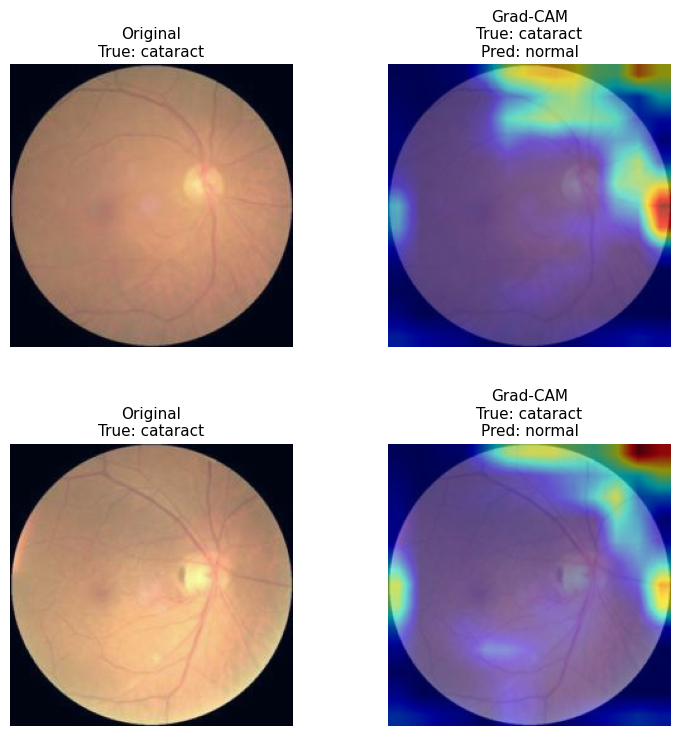


Menampilkan: True cataract → Pred glaucoma


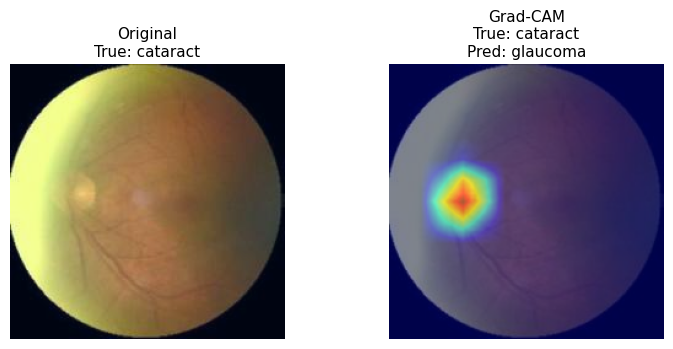


Menampilkan: True glaucoma → Pred normal


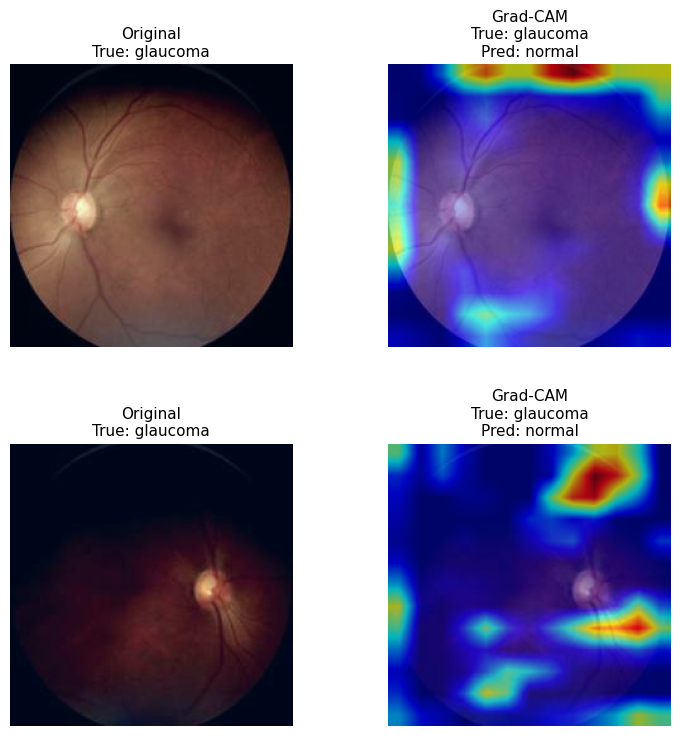


Menampilkan: True glaucoma → Pred cataract


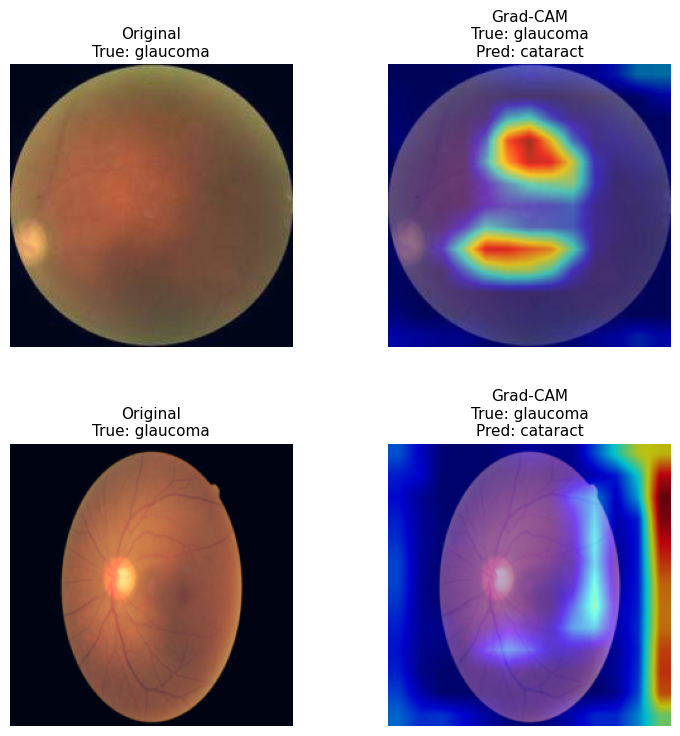


Menampilkan: True normal → Pred glaucoma


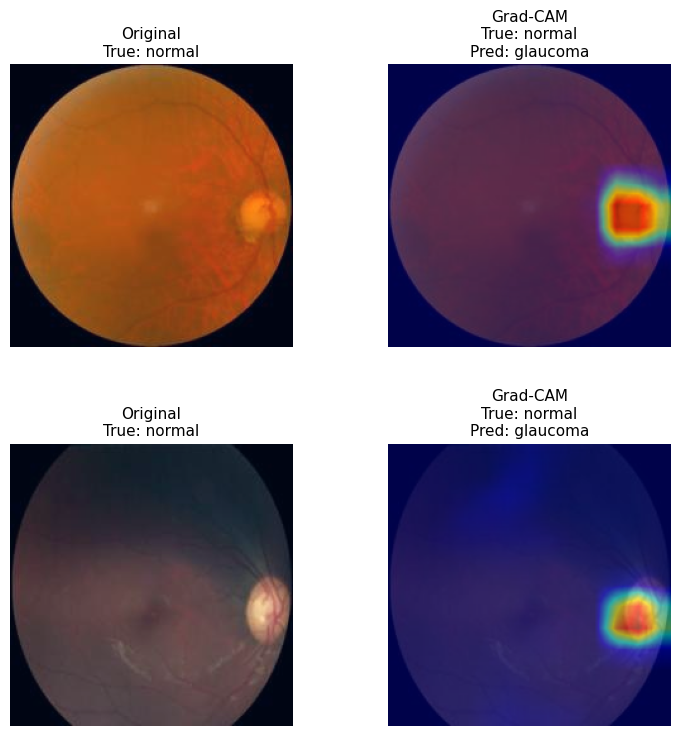


Menampilkan: True normal → Pred cataract


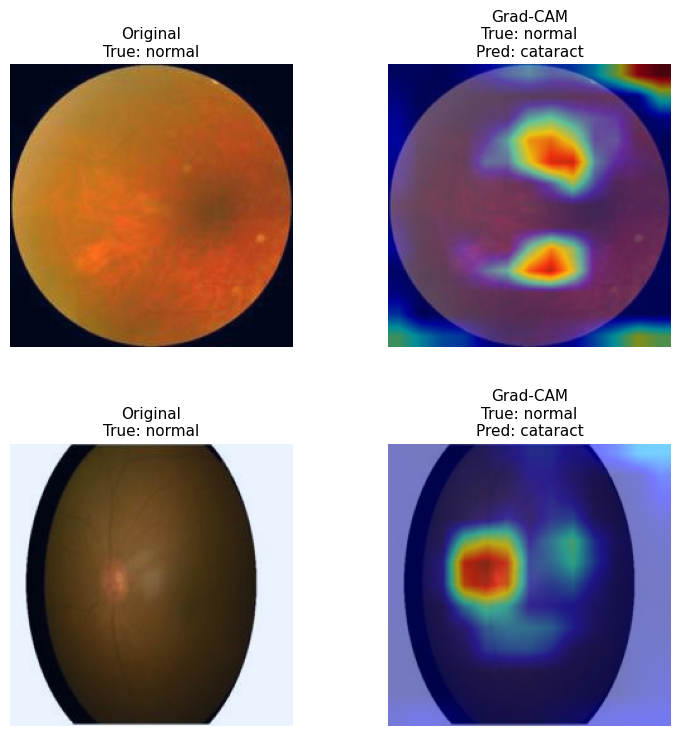


Menampilkan: True normal → Pred diabetic_retinopathy


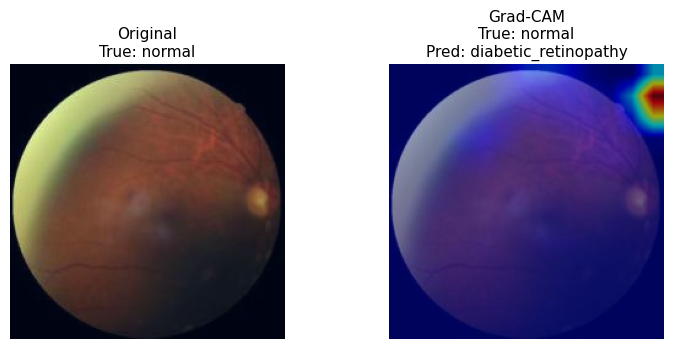

In [21]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import matplotlib.pyplot as plt
import numpy as np
import torch

# ===============================
# EVAL MODE
# ===============================
model.eval()

# ===============================
# CLASS NAMES
# ===============================
class_names = [
    'cataract',
    'diabetic_retinopathy',
    'glaucoma',
    'normal'
]

num_classes = len(class_names)

# ===============================
# TARGET LAYER
# SQUEEZENET FIX
# ===============================
target_layers = [model.features[12].expand3x3]

# ===============================
# INIT CAM
# ===============================
cam = GradCAM(
    model=model,
    target_layers=target_layers
)

# ===============================
# AMBIL MISCLASSIFICATION
# ===============================
misclassified = {}

max_per_pair = 2

# ===============================
# LOOP TEST DATA
# ===============================
for images, labels in test_loader:

    images = images.to(device)
    labels = labels.to(device)

    # IMPORTANT
    images.requires_grad = True

    # ===============================
    # FORWARD
    # ===============================
    outputs = model(images)

    preds = torch.argmax(outputs, dim=1)

    # ===============================
    # CEK MISCLASSIFICATION
    # ===============================
    for i in range(len(labels)):

        true_label = labels[i].item()
        pred_label = preds[i].item()

        # Salah prediksi
        if true_label != pred_label:

            key = (true_label, pred_label)

            # Buat key baru
            if key not in misclassified:
                misclassified[key] = []

            # Simpan beberapa contoh saja
            if len(misclassified[key]) < max_per_pair:

                misclassified[key].append(
                    images[i].detach().cpu()
                )

# ===============================
# PRINT SEMUA ERROR
# ===============================
print("\n=== DAFTAR MISCLASSIFICATION ===")

for (t, p) in misclassified.keys():

    print(
        f"True: {class_names[t]} "
        f"→ Pred: {class_names[p]}"
    )

# ===============================
# VISUALISASI
# ===============================
for (true_label, pred_label), image_list in misclassified.items():

    print(
        f"\nMenampilkan: "
        f"True {class_names[true_label]} "
        f"→ Pred {class_names[pred_label]}"
    )

    # ===============================
    # FIGURE
    # ===============================
    fig, axes = plt.subplots(
        len(image_list),
        2,
        figsize=(8, 4 * len(image_list))
    )

    # Jika hanya 1 gambar
    if len(image_list) == 1:
        axes = np.expand_dims(axes, axis=0)

    # ===============================
    # LOOP IMAGE
    # ===============================
    for idx, image in enumerate(image_list):

        # ===============================
        # INPUT TENSOR
        # ===============================
        input_tensor = image.unsqueeze(0).to(device)

        input_tensor.requires_grad = True

        # ===============================
        # GENERATE CAM
        # ===============================
        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=[
                ClassifierOutputTarget(pred_label)
            ]
        )[0]

        # ===============================
        # DENORMALIZE IMAGE
        # ===============================
        img = image.permute(1, 2, 0).numpy()

        img = (
            img - img.min()
        ) / (
            img.max() - img.min()
        )

        # ===============================
        # OVERLAY CAM
        # ===============================
        visualization = show_cam_on_image(
            img,
            grayscale_cam,
            use_rgb=True
        )

        # ===============================
        # ORIGINAL IMAGE
        # ===============================
        axes[idx, 0].imshow(img)

        axes[idx, 0].set_title(
            f"Original\n"
            f"True: {class_names[true_label]}",
            fontsize=11
        )

        axes[idx, 0].axis("off")

        # ===============================
        # GRAD-CAM
        # ===============================
        axes[idx, 1].imshow(visualization)

        axes[idx, 1].set_title(
            f"Grad-CAM\n"
            f"True: {class_names[true_label]}\n"
            f"Pred: {class_names[pred_label]}",
            fontsize=11
        )

        axes[idx, 1].axis("off")

    # ===============================
    # SHOW
    # ===============================
    plt.tight_layout(pad=3.0)
    plt.show()